In [1]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [47]:
# ── data loading cell ─────────────────────────────────────────────────────────
train  = pd.read_csv("../data/processed/train.csv")
test   = pd.read_csv("../data/processed/test.csv")
val    = pd.read_csv("../data/processed/val.csv")
scaler = jl.load("../models/scaler.pkl")

features = [
    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos",
    "isOutbreak"
]
target = "cases"

xTrain = train[features]
xTest  = test[features]
xVal   = val[features].copy()
yTrain = train[target]
yTest  = test[target]
yVal   = val["cases"].copy()

# wrap in DataFrame to preserve feature names — fixes the warning
xTrainScaled = pd.DataFrame(scaler.transform(xTrain), columns=features)
xValScaled   = pd.DataFrame(scaler.transform(xVal),   columns=features)
xTestScaled  = pd.DataFrame(scaler.transform(xTest),  columns=features)

In [5]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    meanSquareError=mean_squared_error(yTest, predictions)
    r2=r2_score(yTest, predictions)
    rootMeanSquareError=root_mean_squared_error(yTest, predictions)
    meanAbsoluteError=mean_absolute_error(yTest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [48]:
# Linear Regression as baseline model

linearRegression = LinearRegression()
linearRegression.fit(xTrainScaled, yTrain)

timeCv = TimeSeriesSplit(n_splits=5)
cvScore = cross_val_score(linearRegression, xTrainScaled, yTrain, cv=timeCv, scoring='r2')
print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")

# ── val 2019 (outbreak) ───────────────────────────────────────────────────────
yValLr = val["cases"].copy()
print("\n=== Val 2019 (outbreak) ===")
linearEvaluationsVal = regressorEvaluation(linearRegression, xValScaled, yValLr)

# ── test 2020 (final) ─────────────────────────────────────────────────────────
print("\n=== Test 2020 (final) ===")
linearEvaluations = regressorEvaluation(linearRegression, xTestScaled, yTest)

jl.dump(linearRegression, "../models/linear_baseline.pkl")

Cross Validation Average R2 Score: 0.6399
Cross Validation R2 Scores Std: 0.0646
Mean: 0.6399 ± 0.0646

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.6204654728580135
Mean Squared Error: 408.06542216538446
Root Mean Squared Error: 20.200629251718485
Mean Absolute Error: 8.5705148792375

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.42171250081424505
Mean Squared Error: 7.058476371716559
Root Mean Squared Error: 2.6567793231122074
Mean Absolute Error: 1.94540202996665


['../models/linear_baseline.pkl']

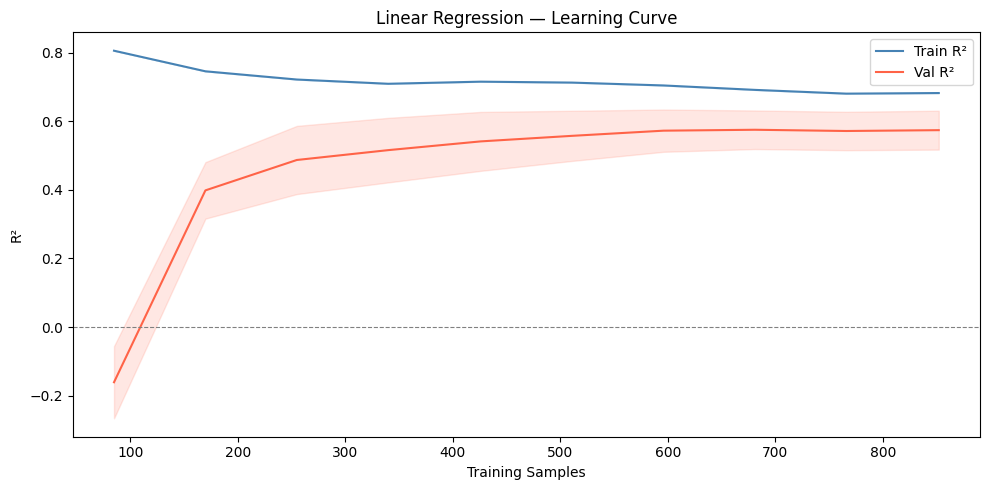

Final train R²: 0.6827 ± 0.0000
Final val   R²: 0.5744 ± 0.0568
Gap:            0.1083


In [50]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

trainSizes, trainScores, valScores = learning_curve(
    linearRegression, xTrainScaled, yTrain,
    cv=TimeSeriesSplit(n_splits=5),   # consistent with RF and XGBoost
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train R²", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val R²", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Linear Regression — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R²: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R²: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'max_depth': 9, 'max_features': 0.8, 'max_samples': 0.9, 'min_samples_leaf': 6, 'min_samples_split': 10}
Best CV R²:  0.7420
CV Mean: 0.7420 ± 0.1781

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.19697096298780759
Mean Squared Error: 863.3954477529046
Root Mean Squared Error: 29.383591471311068
Mean Absolute Error: 11.076047176417362

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8915666304345534
Mean Squared Error: 1.323518800010346
Root Mean Squared Error: 1.1504428712501746
Mean Absolute Error: 0.7154199687976688

Feature importances:
momentum            0.3422
t1_cases            0.3079
month_sin           0.1020
t2_cases            0.0961
week_cos            0.0925
T2M_lag1            0.0093
T2M_mean            0.0092
isOutbreak          0.0082
PRECTOTCORR_lag2    0.0082
WS10M_mean          0.0051
RH2M_mean           0.0048
district_encoded    0.004

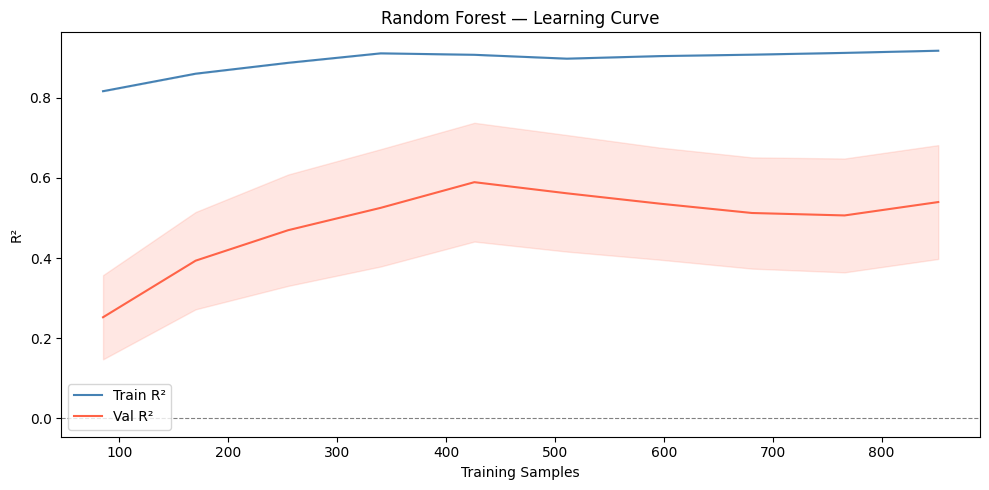

Final train R²: 0.9172 ± 0.0000
Final val   R²: 0.5396 ± 0.1420
Gap:            0.3776


In [51]:
# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, learning_curve
import matplotlib.pyplot as plt
import numpy as np

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetRf = "cases"

xTrainRf = train[featuresRf]
xValRf   = val[featuresRf].copy()
xTestRf  = test[featuresRf].copy()
yTrainRf = train[targetRf]
yValRf   = val[targetRf].copy()
yTestRf  = test[targetRf].copy()

gridParameters = {
    'max_depth':         [7, 8, 9],
    'min_samples_leaf':  [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'max_features':      [0.6, 0.7, 0.8],
    'max_samples':       [0.8, 0.9],
}

tCsv = TimeSeriesSplit(n_splits=5)

gridSearch = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    param_grid=gridParameters,
    cv=tCsv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gridSearch.fit(xTrainRf, yTrainRf)

print(f"Best params: {gridSearch.best_params_}")
print(f"Best CV R²:  {gridSearch.best_score_:.4f}")

rfModel = gridSearch.best_estimator_

scores = cross_val_score(rfModel, xTrainRf, yTrainRf, cv=tCsv, scoring='r2')
print(f"CV Mean: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(rfModel, xValRf, yValRf)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(rfModel, xTestRf, yTestRf)

# feature importance
importance = pd.Series(rfModel.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

jl.dump(rfModel, "../models/rf_regressor.pkl")
print("Saved → ../models/rf_regressor.pkl")

# ── learning curve ────────────────────────────────────────────────────────────
trainSizes, trainScores, valScores = learning_curve(
    rfModel, xTrainRf, yTrainRf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train R²", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val R²", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Random Forest — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R²: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R²: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

[0]	validation_0-rmse:3.99240	validation_1-rmse:3.52179
[100]	validation_0-rmse:1.65357	validation_1-rmse:1.44307
[200]	validation_0-rmse:1.30658	validation_1-rmse:1.20981
[300]	validation_0-rmse:1.14496	validation_1-rmse:1.17660
[400]	validation_0-rmse:1.02630	validation_1-rmse:1.14787
[500]	validation_0-rmse:0.94500	validation_1-rmse:1.12558
[592]	validation_0-rmse:0.88224	validation_1-rmse:1.14263
Best iteration: 542
Best val RMSE:  1.1247
CV Mean: 0.7132 ± 0.1952

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.21972203254699707
Mean Squared Error: 838.9341430664062
Root Mean Squared Error: 28.964359283447266
Mean Absolute Error: 11.16681957244873

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8334460258483887
Mean Squared Error: 2.032928466796875
Root Mean Squared Error: 1.4258079528808594
Mean Absolute Error: 0.9305517673492432


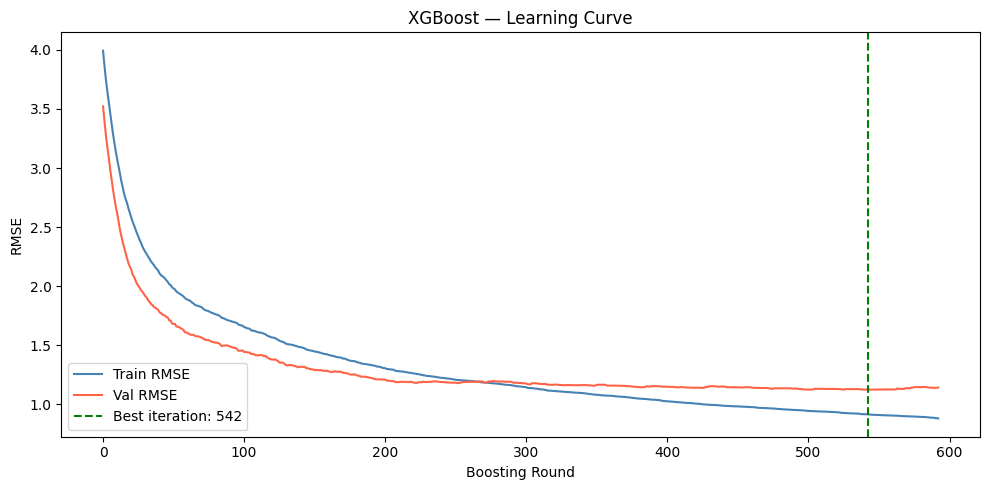

['../models/xgboost_regressor.pkl']

In [53]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor as xgBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"

xTrainXg = train[featuresXg]
xValXg   = val[featuresXg].copy()
xTestXg  = test[featuresXg].copy()
yTrainXg = train[targetXg]
yValXg   = val[targetXg].copy()
yTestXg  = test[targetXg].copy()

# early stopping split — last fold of TimeSeriesSplit
tCsv   = TimeSeriesSplit(n_splits=5)
splits = list(tCsv.split(xTrainXg))
trainIdx, valIdx = splits[-1]

xEarlySplit = xTrainXg.iloc[trainIdx]
yEarlySplit = yTrainXg.iloc[trainIdx]
xValSplit   = xTrainXg.iloc[valIdx]
yValSplit   = yTrainXg.iloc[valIdx]

xgModel = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgModel.fit(
    xEarlySplit, yEarlySplit,
    eval_set=[
        (xEarlySplit, yEarlySplit),
        (xValSplit,   yValSplit)
    ],
    verbose=100
)

print(f"Best iteration: {xgModel.best_iteration}")
print(f"Best val RMSE:  {xgModel.best_score:.4f}")

# CV with fixed n_estimators
xgModelCv = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=xgModel.best_iteration,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgScores = cross_val_score(xgModelCv, xTrainXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"CV Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(xgModel, xValXg, yValXg)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(xgModel, xTestXg, yTestXg)

# ── learning curve ────────────────────────────────────────────────────────────
results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

jl.dump(xgModel, "../models/xgboost_regressor.pkl")

In [54]:
# ── Outbreak RF Regressor (2019 only) ────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import joblib as jl

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]

# val = 2019 data (already loaded)
xTrain2019 = val[featuresRf].copy()
yTrain2019 = val["cases"].copy()

print(f"2019 training rows: {len(xTrain2019)}")
print(f"Cases — mean: {yTrain2019.mean():.2f}, max: {yTrain2019.max():.2f}")

# ── train outbreak RF ─────────────────────────────────────────────────────────
# KFold instead of TimeSeriesSplit — only 1 year of data, 
# TimeSeriesSplit would give tiny folds
rfOutbreak = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=0.7,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

rfOutbreak.fit(xTrain2019, yTrain2019)

# ── evaluate on 2019 itself (sanity check) ────────────────────────────────────
print("\n=== Train fit (2019) ===")
regressorEvaluation(rfOutbreak, xTrain2019, yTrain2019)

# ── CV within 2019 ────────────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=False)   # no shuffle — preserve time order
cvScores = cross_val_score(rfOutbreak, xTrain2019, yTrain2019, cv=kf, scoring='r2')
print(f"\nCV Mean: {cvScores.mean():.4f} ± {cvScores.std():.4f}")

# ── how well does it predict 2020 test? ──────────────────────────────────────
print("\n=== Test 2020 (how outbreak model handles normal year) ===")
regressorEvaluation(rfOutbreak, test[featuresRf], test["cases"])

# ── feature importance ────────────────────────────────────────────────────────
importance = pd.Series(rfOutbreak.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

# ── save ──────────────────────────────────────────────────────────────────────
jl.dump(rfOutbreak, "../models/rf_regressor_outbreak.pkl")
print("\nSaved → ../models/rf_regressor_outbreak.pkl")

2019 training rows: 1728
Cases — mean: 17.92, max: 356.00

=== Train fit (2019) ===
The Model Performance metrics are:
R2 Score: 0.9413854364859479
Mean Squared Error: 63.02081864729344
Root Mean Squared Error: 7.938565276376672
Mean Absolute Error: 2.5535604363217526

CV Mean: 0.8957 ± 0.0591

=== Test 2020 (how outbreak model handles normal year) ===
The Model Performance metrics are:
R2 Score: -17.91792275836052
Mean Squared Error: 230.90886622979585
Root Mean Squared Error: 15.195685776884037
Mean Absolute Error: 8.071765023172262

Feature importances:
momentum            0.4703
t1_cases            0.1887
month_sin           0.1800
week_cos            0.0583
t2_cases            0.0442
T2M_mean            0.0155
PRECTOTCORR_lag1    0.0109
PRECTOTCORR_lag2    0.0086
PRECTOTCORR_sum     0.0055
waterProxy          0.0046
T2M_lag1            0.0036
district_encoded    0.0027
WS10M_mean          0.0026
RH2M_mean           0.0023
isOutbreak          0.0022
dtype: float64

Saved → ../model

2019 training rows: 1728
Cases — mean: 17.92, max: 356.00


c:\Dengue-Outbreak-Predictor\denguePredictor\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_features", "max_samples", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Train fit (2019) ===
The Model Performance metrics are:
R2 Score: 1.0
Mean Squared Error: 2.609420334920287e-06
Root Mean Squared Error: 0.0016153700416907668
Mean Absolute Error: 0.0010361435124650598


c:\Dengue-Outbreak-Predictor\denguePredictor\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_features", "max_samples", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Dengue-Outbreak-Predictor\denguePredictor\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_features", "max_samples", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Dengue-Outbreak-Predictor\denguePredictor\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_features", "max_samples", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Dengue-Outbre


CV Mean: 0.8957 ± 0.0330

=== Test 2020 (how outbreak model handles normal year) ===
The Model Performance metrics are:
R2 Score: -18.86512565612793
Mean Squared Error: 242.47027587890625
Root Mean Squared Error: 15.571456909179688
Mean Absolute Error: 7.84102725982666

Feature importances:
month_sin           0.5176
momentum            0.3297
week_cos            0.1159
t2_cases            0.0145
t1_cases            0.0108
waterProxy          0.0031
PRECTOTCORR_lag2    0.0021
isOutbreak          0.0015
T2M_mean            0.0011
PRECTOTCORR_lag1    0.0011
district_encoded    0.0007
RH2M_mean           0.0007
PRECTOTCORR_sum     0.0006
WS10M_mean          0.0003
T2M_lag1            0.0003
dtype: float32


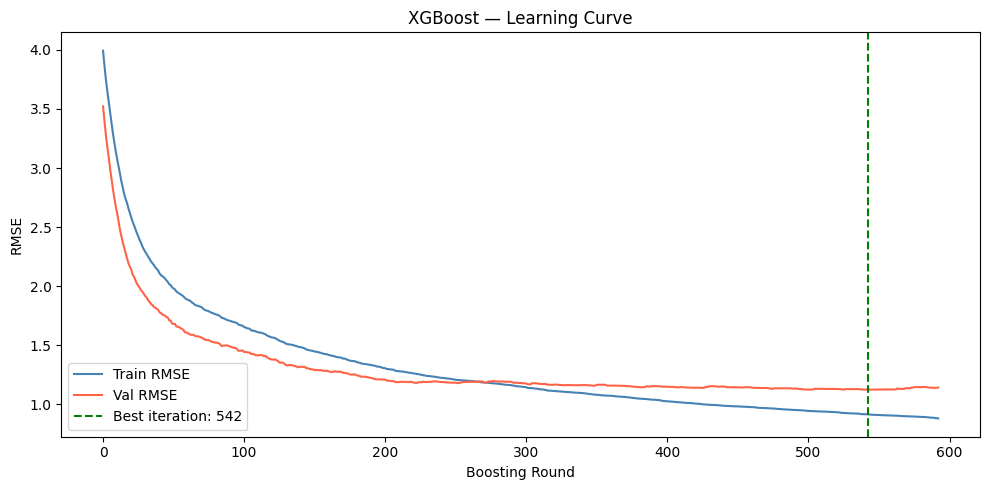


Saved → ../models/xg_regressor_outbreak.pkl


In [ ]:
# ── Outbreak xgboost Regressor (2019 only) ────────────────────────────────────────
from xgboost import XGBRegressor

featuresxg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]

# val = 2019 data (already loaded)
xTrain2019 = val[featuresxg].copy()
yTrain2019 = val["cases"].copy()

print(f"2019 training rows: {len(xTrain2019)}")
print(f"Cases — mean: {yTrain2019.mean():.2f}, max: {yTrain2019.max():.2f}")

# ── train outbreak xgboost ─────────────────────────────────────────────────────────
# KFold instead of TimeSeriesSplit — only 1 year of data, 
# TimeSeriesSplit would give tiny folds
xgOutbreak = XGBRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgOutbreak.fit(xTrain2019, yTrain2019)

# ── evaluate on 2019 itself (sanity check) ────────────────────────────────────
print("\n=== Train fit (2019) ===")
regressorEvaluation(xgOutbreak, xTrain2019, yTrain2019)

# ── CV within 2019 ────────────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=False)   # no shuffle — preserve time order
cvScores = cross_val_score(xgOutbreak, xTrain2019, yTrain2019, cv=kf, scoring='r2')
print(f"\nCV Mean: {cvScores.mean():.4f} ± {cvScores.std():.4f}")

# ── how well does it predict 2020 test? ──────────────────────────────────────
print("\n=== Test 2020 (how outbreak model handles normal year) ===")
regressorEvaluation(xgOutbreak, test[featuresxg], test["cases"])

# ── feature importance ────────────────────────────────────────────────────────
importance = pd.Series(xgOutbreak.feature_importances_, index=featuresxg).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))
results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()
# ── save ──────────────────────────────────────────────────────────────────────
jl.dump(xgOutbreak, "../models/xg_regressor_outbreak.pkl")
print("\nSaved → ../models/xg_regressor_outbreak.pkl")